In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns

In [2]:
df_2023 = pd.read_csv('josaa_2023_all_institutes_full.csv')
df_2024 = pd.read_csv('josaa_2024_reparsed_all_institutes.csv')
df_2025 = pd.read_csv('josaa_2025_opening_closing_ranks_all_institutes.csv')

In [3]:
df_2023['Year'] = 2023
df_2024['Year'] = 2024
df_2025['Year'] = 2025

In [4]:
df = pd.concat([df_2023, df_2024, df_2025], ignore_index=True)

In [5]:
df.to_csv('combined_josaa_data_2023_to_2025.csv', index=False)
print("Successfully saved combined data to 'combined_josaa_data_2023_to_2025.csv'")

Successfully saved combined data to 'combined_josaa_data_2023_to_2025.csv'


In [6]:
df.head()

,Institute,Academic Program Name,Quota,Seat Type,Gender,Opening Rank,Closing Rank,Year
0,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OPEN,Gender-Neutral,9462,12911,2023
1,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OPEN,Female-only (including Supernumerary),16218,19272,2023
2,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,EWS,Gender-Neutral,1852,1977,2023
3,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,EWS,Female-only (including Supernumerary),3056,3056,2023
4,Indian Institute of Technology Bhubaneswar,"Civil Engineering (4 Years, Bachelor of Techno...",AI,OBC-NCL,Gender-Neutral,4014,4642,2023


In [7]:
df.describe()

,Year
count,34804.000000
mean,2024.041173
std,0.813959
min,2023.000000
25%,2023.000000
50%,2024.000000
75%,2025.000000
max,2025.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34804 entries, 0 to 34803
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Institute              34804 non-null  object
 1   Academic Program Name  34804 non-null  object
 2   Quota                  34804 non-null  object
 3   Seat Type              34804 non-null  object
 4   Gender                 34804 non-null  object
 5   Opening Rank           34804 non-null  object
 6   Closing Rank           34804 non-null  object
 7   Year                   34804 non-null  int64 
dtypes: int64(1), object(7)
memory usage: 2.1+ MB


In [9]:
df.isnull().sum()

Institute                0
Academic Program Name    0
Quota                    0
Seat Type                0
Gender                   0
Opening Rank             0
Closing Rank             0
Year                     0
dtype: int64

In [10]:
features = ['Institute', 'Academic Program Name', 'Quota', 'Seat Type', 'Gender', 'Year']
target = 'Closing Rank'

In [11]:
# Clean the 'Closing Rank' column
df[target] = df[target].astype(str).str.replace('P', '')
df[target] = pd.to_numeric(df[target], errors='coerce')

In [12]:
df.dropna(subset=[target], inplace=True)
df[target] = df[target].astype(int)

In [13]:
print(f"NaNs in Closing Rank after cleaning: {df[target].isnull().sum()}")

NaNs in Closing Rank after cleaning: 0


In [14]:
X = df[features]
y = df[target]

In [15]:
X = pd.get_dummies(X, columns=['Institute', 'Academic Program Name', 'Quota', 'Seat Type', 'Gender'], drop_first=True)

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
from sklearn.linear_model import LinearRegression,ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeRegressor  

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1), 
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "ElasticNet": ElasticNet(random_state=42)
}

In [19]:
results = {}
trained_models = {} # Dictionary to store the trained models

In [20]:
for name, model in models.items():
    print(f"\nTraining {name} model...")
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    
    results[name] = [mae, r2]
    trained_models[name] = model # Save the trained model object
    print(f"{name} training complete.")


Training Linear Regression model...
Linear Regression training complete.

Training Random Forest model...
Random Forest training complete.

Training Gradient Boosting model...
Gradient Boosting training complete.

Training Decision Tree model...
Decision Tree training complete.

Training ElasticNet model...
ElasticNet training complete.


In [21]:
print("\n\n--- Model Performance Comparison ---")
results_df = pd.DataFrame(results, index=['Mean Absolute Error (MAE)', 'R-squared (R2)']).T
results_df['Mean Absolute Error (MAE)'] = results_df['Mean Absolute Error (MAE)'].round(2)
results_df['R-squared (R2)'] = results_df['R-squared (R2)'].round(4)



--- Model Performance Comparison ---


In [22]:
print(results_df)
print("\n--- Conclusion ---")
print("Lower MAE is better. Higher R-squared (closer to 1.0) is better.")

                   Mean Absolute Error (MAE)  R-squared (R2)
Linear Regression                   10668.61          0.4296
Random Forest                        2333.52          0.8651
Gradient Boosting                    6901.72          0.7568
Decision Tree                        2405.65          0.8153
ElasticNet                          11656.40          0.1063

--- Conclusion ---
Lower MAE is better. Higher R-squared (closer to 1.0) is better.


In [23]:
import pickle
# --- 6. Save the Best Model (Random Forest) AND the Columns ---
print("\nSaving the best model (Random Forest) and its columns...")

# **THIS IS THE FIX**: Select the trained Random Forest model from the dictionary
best_model = trained_models["Random Forest"]

# Save the trained model
with open('college_predictor.pkl', 'wb') as file:
    pickle.dump(best_model, file)

# Save the list of columns the model was trained on
with open('model_columns.pkl', 'wb') as file:
    pickle.dump(X_train.columns, file)

print("\nSuccessfully saved 'college_predictor.pkl' and 'model_columns.pkl'.")


Saving the best model (Random Forest) and its columns...

Successfully saved 'college_predictor.pkl' and 'model_columns.pkl'.


Generating predictions and calculating residuals...
Creating and saving the histogram...

Successfully generated and saved 'residuals_histogram.png'.


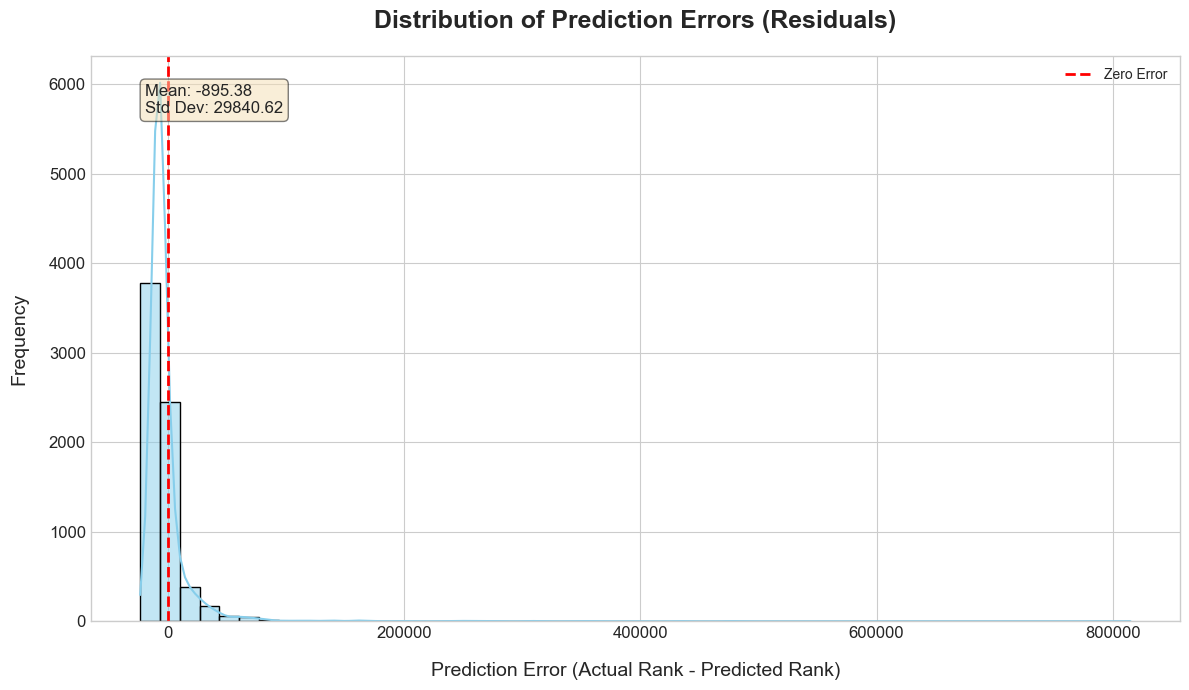

In [24]:
print("Generating predictions and calculating residuals...")
y_pred = model.predict(X_test)
residuals = y_test - y_pred


# --- 4. Create and Save the Histogram ---
print("Creating and saving the histogram...")
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 7))

# Plot the histogram
sns.histplot(residuals, bins=50, kde=True, ax=ax, color='skyblue', edgecolor='black')

# Add a vertical line at zero for reference
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')

# Set titles and labels for clarity
ax.set_title('Distribution of Prediction Errors (Residuals)', fontsize=18, weight='bold', pad=20)
ax.set_xlabel('Prediction Error (Actual Rank - Predicted Rank)', fontsize=14, labelpad=15)
ax.set_ylabel('Frequency', fontsize=14, labelpad=15)
ax.legend()

# Improve tick label appearance
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add a text box explaining the distribution
stats_text = f"Mean: {residuals.mean():.2f}\nStd Dev: {residuals.std():.2f}"
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=props)

# Final layout adjustments and save
plt.tight_layout()
plt.savefig('residuals_histogram.png', dpi=300) # Save with high resolution

print("\nSuccessfully generated and saved 'residuals_histogram.png'.")

# To display the plot if running interactively
plt.show()


Creating and saving the scatter plot...

Successfully generated and saved 'scatterplot_actual_vs_predicted.png'.


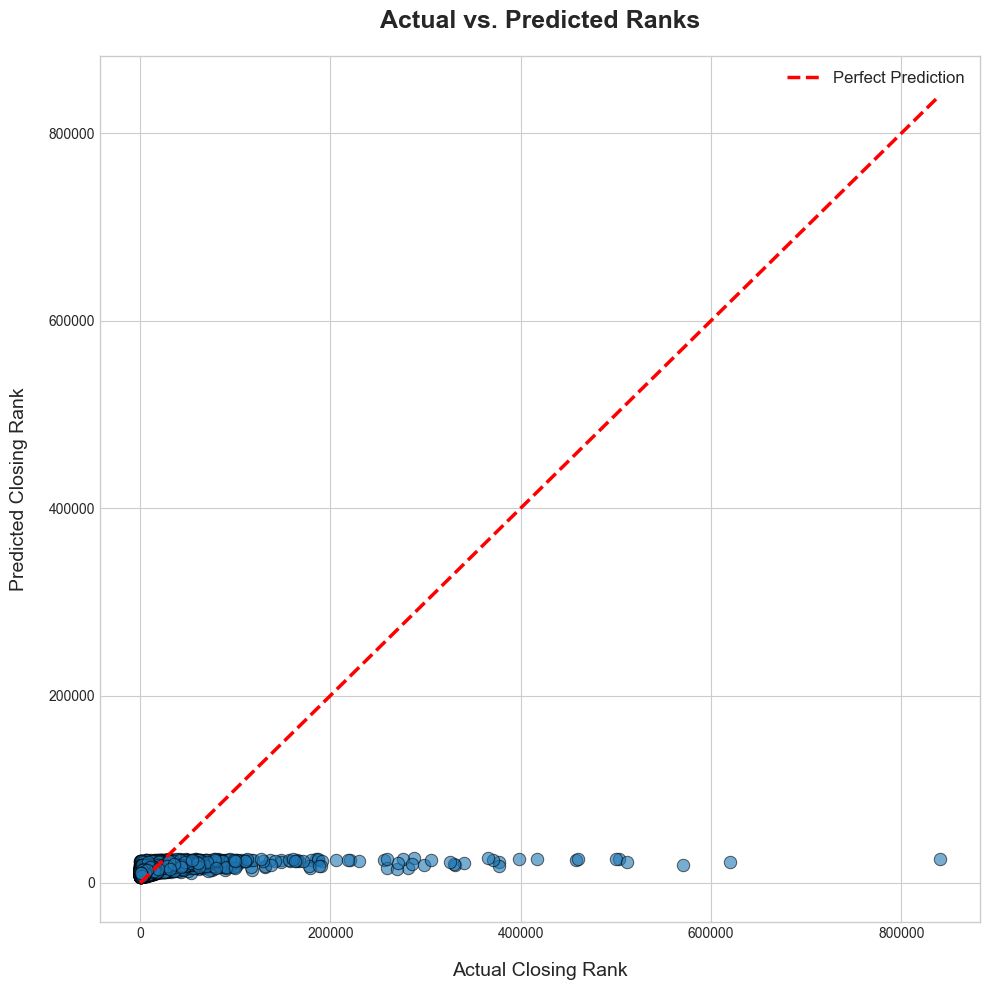

In [25]:
print("\nCreating and saving the scatter plot...")

fig3, ax3 = plt.subplots(figsize=(10, 10))

# Create the scatter plot
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, ax=ax3, edgecolor='k', s=80)

# Add a line for perfect predictions (y=x)
max_rank = max(y_test.max(), y_pred.max())
min_rank = min(y_test.min(), y_pred.min())
ax3.plot([min_rank, max_rank], [min_rank, max_rank], color='red', linestyle='--', linewidth=2.5, label='Perfect Prediction')

# Set titles and labels
ax3.set_title('Actual vs. Predicted Ranks', fontsize=18, weight='bold', pad=20)
ax3.set_xlabel('Actual Closing Rank', fontsize=14, labelpad=15)
ax3.set_ylabel('Predicted Closing Rank', fontsize=14, labelpad=15)
ax3.legend(fontsize=12)
ax3.grid(True)

# Improve layout and save
plt.tight_layout()
plt.savefig('scatterplot_actual_vs_predicted.png', dpi=300)

print("\nSuccessfully generated and saved 'scatterplot_actual_vs_predicted.png'.")


# To display the plots if running interactively
plt.show()
